# UpSet plots & intersections

Generates upset plots in [Fig. 2](figures/figure_2) and [Fig. 6](figures/figure_6) as well as [Supplementary Table 6](results/Supplementary_Table_6_Hit_Intersections.xlsx).

Note: if this notebook will not run with the main `orb-selection` conda environment for this repo, try the [`upset_env.yml`](upset_env.yml) environment instead.

## Notebook Workflow

1. Load significant gene-ID lists from each analysis branch.
2. Build set intersections and UpSet visualizations.
3. Optionally intersect with silk-gland-associated gene sets.
4. Save publication-ready figures to `figures/`.

In [11]:
import os
import sys
import pip
import warnings
!{sys.executable} -m pip install openpyxl
import upsetplot as up
import matplotlib.pyplot as plt
import pandas as pd

# Resolve repo root whether cwd is repo root, scripts/, or a stage subdirectory.
cwd = os.getcwd()
if os.path.basename(cwd) == "orb-selection":
    repo_root = cwd
elif os.path.basename(os.path.dirname(cwd)) == "orb-selection":
    repo_root = os.path.dirname(cwd)
elif os.path.basename(os.path.dirname(os.path.dirname(cwd))) == "orb-selection":
    repo_root = os.path.dirname(os.path.dirname(cwd))
else:
    repo_root = cwd

data = os.path.join(repo_root, "data")

src_path = os.path.join(repo_root, "src")
stage03_path = os.path.join(repo_root, "scripts", "03_selection_tests")
stage04_path = os.path.join(repo_root, "scripts", "04_permulation_loss_dup")
for path in (src_path, stage03_path, stage04_path):
    if path not in sys.path:
        sys.path.insert(0, path)

print(f"Using src path: {src_path}")
print(f"Using stage-03 path: {stage03_path}")
print(f"Using stage-04 path: {stage04_path}")

# Import the modules from src/
from hyphy_results_parser import (
    RelaxResult,
    BustedPhResult
)
from odds_ratio_test import PermutationTestResults
from id_converter import convert_hogs_to_locs, convert_locs_to_hogs, get_ptep_description, get_udiv_best_blast

import get_silk_genes as silk

# Define paths to data and results directories
data = os.path.join(repo_root, "data")
figures = os.path.join(repo_root, "figures")
assets = os.path.join(repo_root, "assets")
results = os.path.join(repo_root, "results")

# Suppress FutureWarnings and SyntaxWarnings from libraries (especially upsetplot)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=SyntaxWarning)

%load_ext autoreload

up.__version__

Using src path: /Users/calvin/orb-selection/src
Using stage-03 path: /Users/calvin/orb-selection/scripts/03_selection_tests
Using stage-04 path: /Users/calvin/orb-selection/scripts/04_permulation_loss_dup
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'0.9.0'

## Read all the hit lists into a dictionary (as HOGs)

In [12]:
hits_lists = {}

### Silk gland genes & spidroins

In [13]:
%autoreload 2
silk_genes_list = silk.get_all_silk_genes(data)
spidroins_list = pd.read_csv(f'{data}/spidroins_LOCs.tsv', sep='\t', dtype=str)['LOC'].tolist()

# There may end up being LOCs in these HOGs that are not in my silk gland gene list
# or spidroin list. However, if they are orthologous to those LOCs, they are still relevant.
silk_hogs = convert_locs_to_hogs(silk_genes_list, f'{data}/N5.tsv')
spidroin_hogs = convert_locs_to_hogs(spidroins_list, f'{data}/N5.tsv')

# These lists of HOGs are longer than the original lists of LOCs, meaning some LOCs 
# belong to multiple HOGs. This may be because multiple isoforms of the gene were 
# included in the original Orthofinder analysis.
hits_lists['silk_genes'] = list(set(silk_hogs['HOG'].tolist()))
# hits_lists['spidroins'] = list(set(spidroin_hogs['HOG'].tolist()))

### Hyphy results

In [14]:
hyphy_results = results + "/hyphy_results_cache/"

# Load the saved RELAX results
relax_result = RelaxResult.load_from_pickle(str(hyphy_results + "relax_results.pkl"))
relax_result_fltrd = relax_result.filter_omega(10000)
relax_df_fltrd = relax_result_fltrd.results_df
hits_lists['relaxed_in_nonorb'] = list(relax_df_fltrd[relax_df_fltrd['result']=='relaxed'].index)
hits_lists['intensified_in_nonorb'] = list(relax_df_fltrd[relax_df_fltrd['result']=='intensified'].index)

# Load the saved BUSTED-PH results
busted_ph_result = BustedPhResult.load_from_pickle(str(hyphy_results + "busted_ph_orb_results.pkl"))
busted_ph_result_fltrd = busted_ph_result.filter_omega(10000)
busted_ph_df_fltrd = busted_ph_result_fltrd.results_df
hits_lists['positive_sel_in_orb'] = list(busted_ph_df_fltrd[busted_ph_df_fltrd['result']=='hit'].index)

# Load the saved BUSTED-PH-REV results
busted_ph_rev_result = BustedPhResult.load_from_pickle(str(hyphy_results + "busted_ph_non_orb_results.pkl"))


busted_ph_rev_result_fltrd = busted_ph_rev_result.filter_omega(10000)
busted_ph_rev_df_fltrd = busted_ph_rev_result_fltrd.results_df
hits_lists['positive_sel_in_nonorb'] = list(busted_ph_rev_df_fltrd[busted_ph_rev_df_fltrd['result']=='hit'].index)

### Odds ratio test results

In [15]:
perm_test_results_dir = os.path.join(repo_root, "results/odds_ratio_test/Results_Aug12/Run1_occ_30-88_10000x")
perm_results = pd.read_csv(os.path.join(perm_test_results_dir, "fltrd_hits.csv"), index_col="HOG")

In [16]:
perm_results

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant by avgd thresholds,Significant by permulation
HOG,,,,,,,,,
N5.HOG0001041,46,2.521478,-0.155768,0.0009,0.9991,0.4798,0.5202,NaN,loss_fg
N5.HOG0001627,33,1.855831,-3.857911,0.0640,0.9360,0.9873,0.0127,dup_bg,dup_bg
N5.HOG0002031,46,-3.395453,1.332164,0.9984,0.0016,0.4120,0.5880,loss_bg,loss_bg
N5.HOG0002072,52,3.079265,-0.639315,0.0143,0.9857,0.8034,0.1964,loss_fg,loss_fg
N5.HOG0002076,55,-2.050543,0.725386,0.9545,0.0455,0.1584,0.8416,NaN,loss_bg
...,...,...,...,...,...,...,...,...,...
N5.HOG0073071,35,-2.150469,2.393444,0.7460,0.2540,0.0113,0.9887,dup_fg,dup_fg
N5.HOG0073090,32,1.527411,-1.712408,0.0256,0.9744,0.9150,0.0850,NaN,loss_fg
N5.HOG0073180,32,-1.042447,0.851411,0.9953,0.0047,0.1060,0.8940,NaN,loss_bg


Break down into HOGs that were more likely to be missing or in multiple copies in orbweavers or in non-orbweavers

In [17]:
hits_lists['duplication_more_likely_orb'] = list(perm_results[perm_results["P-value duplication more likely in fg"] <= 0.05].index)
hits_lists['duplication_more_likely_nonorb'] = list(perm_results[perm_results["P-value duplication more likely in bg"] <= 0.05].index)
hits_lists['loss_more_likely_orb'] = list(perm_results[perm_results["P-value loss more likely in fg"] <= 0.05].index)
hits_lists['loss_more_likely_nonorb'] = list(perm_results[perm_results["P-value loss more likely in bg"] <= 0.05].index)

### PhyloGLM results

In [18]:
phyloglm = pd.read_csv(f'{results}/phyloglm/phyloglm_p_adj.csv', index_col="HOG")
phyloglm_sig = phyloglm[phyloglm["p_adj_bonferroni"] <= 0.05]
phyloglm_sig

,error,coef_(Intercept)_Estimate,coef_(Intercept)_StdErr,coef_(Intercept)_z.value,coef_(Intercept)_p.value,coef_orb_weavingTRUE_Estimate,coef_orb_weavingTRUE_StdErr,coef_orb_weavingTRUE_z.value,coef_orb_weavingTRUE_p.value,p_adj_bonferroni
HOG,,,,,,,,,,
N5.HOG0067161,NaN,-0.131217,0.111454,-1.177318,0.239069,0.462570,0.050010,9.249622,2.252871e-20,2.695110e-16
N5.HOG0062479,NaN,-0.102667,0.072843,-1.409441,0.158705,0.283759,0.032246,8.799725,1.371518e-18,1.640747e-14
N5.HOG0068083,NaN,-0.116300,0.102023,-1.139940,0.254311,0.391135,0.045379,8.619335,6.734435e-18,8.056405e-14
N5.HOG0068230,NaN,0.118418,0.062018,1.909418,0.056208,-0.274228,0.032937,-8.325893,8.369532e-17,1.001247e-12
N5.HOG0030400,NaN,1.146628,0.302901,3.785491,0.000153,-1.144605,0.137932,-8.298313,1.056000e-16,1.263293e-12
...,...,...,...,...,...,...,...,...,...,...
N5.HOG0066701,NaN,0.203044,0.124608,1.629462,0.103215,-0.312257,0.067792,-4.606109,4.102731e-06,4.908098e-02
N5.HOG0060348,NaN,0.493869,0.236504,2.088208,0.036779,-1.055627,0.229242,-4.604867,4.127303e-06,4.937492e-02
N5.HOG0061162,NaN,0.178121,0.154513,1.152796,0.248994,0.314913,0.068417,4.602884,4.166809e-06,4.984754e-02


In [19]:
# hits_lists['phyloglm_fg'] = list(phyloglm_sig[phyloglm_sig["coef_orb_weavingTRUE_Estimate"] > 0].index)
# hits_lists['phyloglm_bg'] = list(phyloglm_sig[phyloglm_sig["coef_orb_weavingTRUE_Estimate"] < 0].index)
hits_lists['phyloglm'] = list(phyloglm_sig.index)

In [20]:
print("Hits lists:")
for category, hits in hits_lists.items():
    print(f"  {category}: {len(hits)}") 

Hits lists:
  silk_genes: 481
  relaxed_in_nonorb: 405
  intensified_in_nonorb: 737
  positive_sel_in_orb: 93
  positive_sel_in_nonorb: 235
  duplication_more_likely_orb: 464
  duplication_more_likely_nonorb: 514
  loss_more_likely_orb: 237
  loss_more_likely_nonorb: 407
  phyloglm: 337


## UpSet plot of Hyphy results only

In [21]:
hyphy_upset_dict = {
    'Positive selection ~ $\it{non}$-orbweaving': hits_lists['positive_sel_in_nonorb'],
    'Positive selection ~ orbweaving': hits_lists['positive_sel_in_orb'],
    'Selection $\it{intensified}$ in non-orbweavers': hits_lists['intensified_in_nonorb'],
    'Selection $\it{relaxed}$ in non-orbweavers': hits_lists['relaxed_in_nonorb'],
}

upset_data = up.from_contents(hyphy_upset_dict)

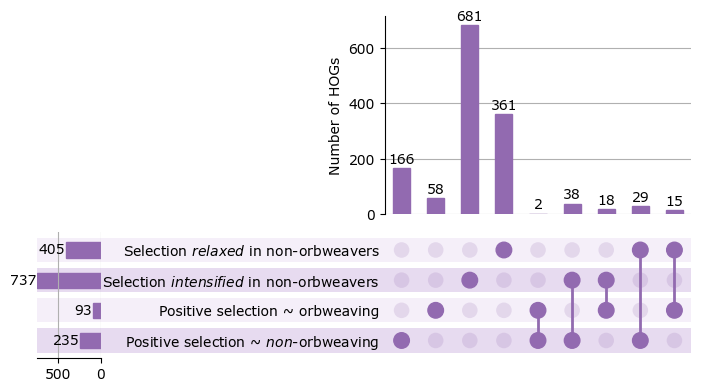

In [22]:
%autoreload 2
upset = up.UpSet(
    upset_data, show_counts=True, sort_categories_by=None, facecolor='#926AB0'
 )

# Only style categories that exist in the data
for cat, bar_color, shade_color in [
    ('Selection $\it{relaxed}$ in non-orbweavers', '#926AB0', '#F5EFF9'),
    ('Selection $\it{intensified}$ in non-orbweavers', '#926AB0', '#E7DBF0'),
    ('Positive selection ~ orbweaving', '#926AB0', '#F5EFF9'),
    ('Positive selection ~ $\it{non}$-orbweaving', '#926AB0', '#E7DBF0'),
]:
    if cat in hyphy_upset_dict:
        upset.style_categories(cat, bar_facecolor=bar_color, shading_facecolor=shade_color)

upset.plot()
plt.ylabel('Number of HOGs')
plt.rcParams['font.family'] = 'Verdana'
plt.gcf().savefig(str(figures + '/figure_2/hyphy_upset.png'), dpi=300, transparent=True, bbox_inches='tight')
plt.show()

## UpSet plot of Hyphy results + silk genes/spidroins

In [23]:
upset_dict_with_silk = hyphy_upset_dict.copy()
upset_dict_with_silk['Silk gland-associated genes'] = hits_lists['silk_genes']

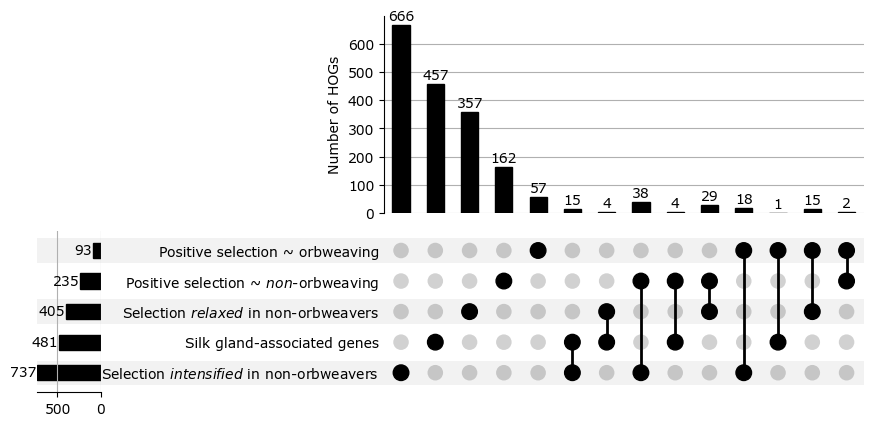

In [24]:
upset_data_with_silk = up.from_contents(upset_dict_with_silk)

upset = up.UpSet(
    upset_data_with_silk, show_counts=True,
)

upset.plot()
plt.ylabel('Number of HOGs')
plt.rcParams['font.family'] = 'Verdana'

# Odds ratio test upset

In [25]:
upset_dict_with_ort = {}

upset_dict_with_ort["Gene count ~ orb-weaving"] = hits_lists['phyloglm']
upset_dict_with_ort['Duplication more likely in non-\norb-weavers'] = hits_lists['duplication_more_likely_nonorb']
upset_dict_with_ort['Duplication more likely in orb-weavers'] = hits_lists['duplication_more_likely_orb']
upset_dict_with_ort['Loss more likely in non-orb-weavers'] = hits_lists['loss_more_likely_nonorb']
upset_dict_with_ort['Loss more likely in orb-weavers'] = hits_lists['loss_more_likely_orb']

Text(0.5, 1.0, 'Odds ratio test')

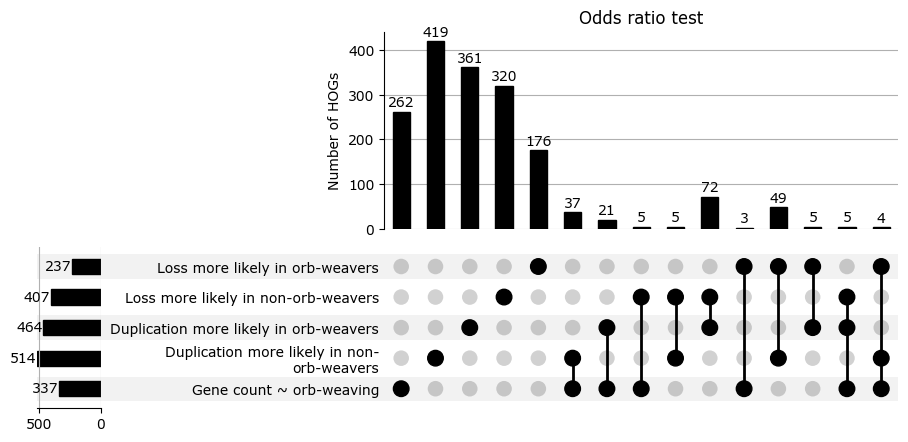

In [26]:
upset_data_with_ort = up.from_contents(upset_dict_with_ort)

upset = up.UpSet(
    upset_data_with_ort, show_counts=True, sort_categories_by=None
)

upset.plot()
plt.ylabel('Number of HOGs')
plt.rcParams['font.family'] = 'Verdana'
plt.title('Odds ratio test')
# 
# plt.savefig(str(figures + '/figure_5/ort_upset.png'), dpi=300, transparent=False, bbox_inches='tight')

1744 total

## Odds ratio test upset with silk genes/spidroins

In [27]:
upset_dict_with_silk_ort = upset_dict_with_ort.copy()
upset_dict_with_silk_ort['Silk gland-associated genes'] = hits_lists['silk_genes']


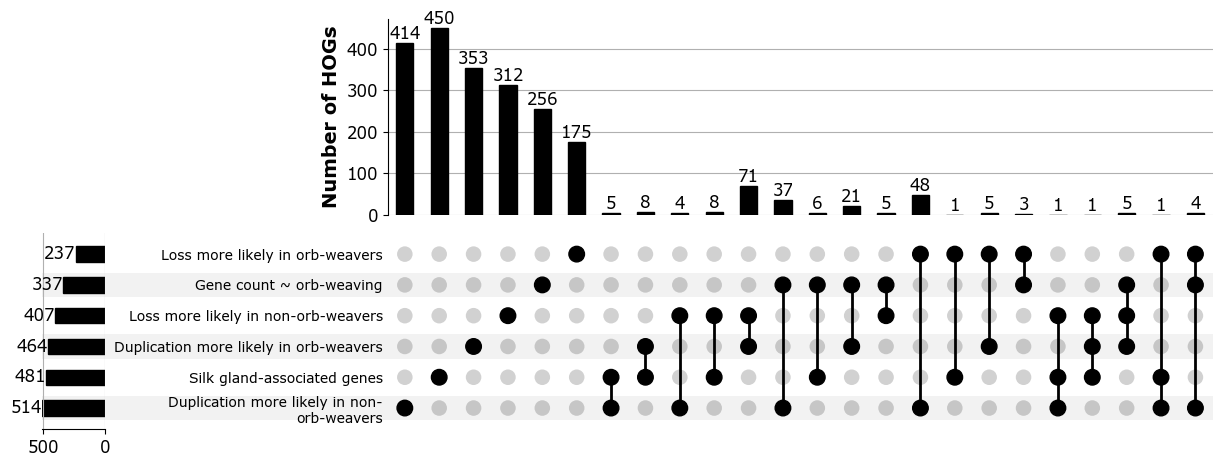

In [28]:
upset_data_with_silk_ort = up.from_contents(upset_dict_with_silk_ort)

upset = up.UpSet(
    upset_data_with_silk_ort, show_counts=False,
)

upset.plot()
plt.ylabel('Number of HOGs', fontsize=14, fontweight='bold')
plt.rcParams['font.family'] = 'Verdana'
plt.tick_params(axis='y', labelsize=12)

for ax in plt.gcf().axes:
    for bar in ax.containers:
        ax.bar_label(bar, fontsize=12)  # Bar numerical labels top
    if hasattr(ax, 'get_xticklabels'):
        plt.setp(ax.get_xticklabels(), fontsize=12) # Bar numerical labels bottom

# plt.savefig(str(figures + '/figure_5/ort_silk_upset_plot.png'), dpi=300, transparent=False, bbox_inches='tight')


In [29]:
upset_dict_massive = upset_dict_with_ort | upset_dict_with_silk
# upset_dict_massive_50 = dict(reversed(list(upset_dict_massive_50.items())))
upset_dict_massive['Silk gland-associated genes'] = hits_lists['silk_genes']

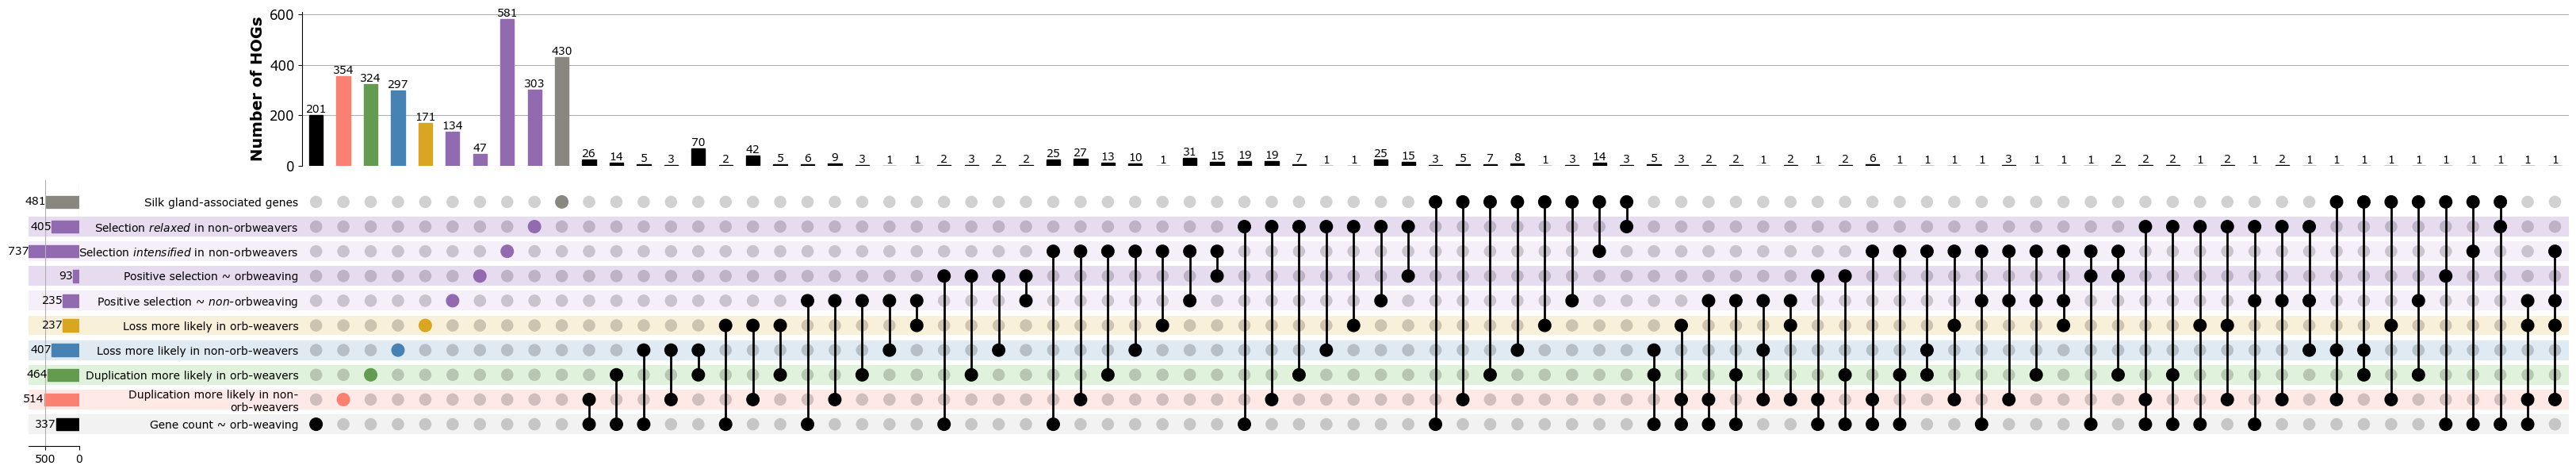

In [30]:
upset_data_massive = up.from_contents(upset_dict_massive)

upset = up.UpSet(
    upset_data_massive,
    sort_categories_by=None
)

upset.style_categories('Selection $\it{relaxed}$ in non-orbweavers', bar_facecolor='#926AB0', shading_facecolor="#E7DBF0")
upset.style_categories('Selection $\it{intensified}$ in non-orbweavers', bar_facecolor='#926AB0', shading_facecolor='#F5EFF9')
upset.style_categories('Positive selection ~ orbweaving', bar_facecolor='#926AB0', shading_facecolor="#E7DBF0")
upset.style_categories('Positive selection ~ $\it{non}$-orbweaving', bar_facecolor='#926AB0', shading_facecolor="#F5EFF9")
# upset.style_categories('Selection $\it{relaxed}$ in non-orbweavers', bar_facecolor='#FA8072', shading_facecolor='#FEE9E7')
# upset.style_categories('Positive selection ~ orbweaving', bar_facecolor='#4682B4', shading_facecolor='#E0EAF2')
# upset.style_categories('Positive selection ~ $\it{non}$-orbweaving', bar_facecolor='#DAA520', shading_facecolor='#F9F0D9')
# upset.style_categories('Selection $\it{intensified}$ in non-orbweavers', bar_facecolor='#639B51', shading_facecolor='#E0F2DB')

upset.style_subsets(present=['Selection $\it{relaxed}$ in non-orbweavers'], 
                    absent=list(set(upset_dict_massive.keys()) - {'Selection $\it{relaxed}$ in non-orbweavers'}),
                    facecolor="#926AB0")
upset.style_subsets(present=['Positive selection ~ orbweaving'], 
                    absent=list(set(upset_dict_massive.keys()) - {'Positive selection ~ orbweaving'}),
                    facecolor="#926AB0")
upset.style_subsets(present=['Selection $\it{intensified}$ in non-orbweavers'], 
                    absent=list(set(upset_dict_massive.keys()) - {'Selection $\it{intensified}$ in non-orbweavers'}),
                    facecolor="#926AB0")
upset.style_subsets(present=['Positive selection ~ $\it{non}$-orbweaving'], 
                    absent=list(set(upset_dict_massive.keys()) - {'Positive selection ~ $\it{non}$-orbweaving'}),
                    facecolor="#926AB0")

upset.style_categories('Duplication more likely in non-\norb-weavers', bar_facecolor='#FA8072', shading_facecolor='#FEE9E7')
upset.style_categories('Loss more likely in non-orb-weavers', bar_facecolor='#4682B4', shading_facecolor='#E0EAF2')
upset.style_categories('Loss more likely in orb-weavers', bar_facecolor='#DAA520', shading_facecolor='#F9F0D9')
upset.style_categories('Duplication more likely in orb-weavers', bar_facecolor='#639B51', shading_facecolor='#E0F2DB')
upset.style_categories('Silk gland-associated genes', bar_facecolor='#8a8680', shading_facecolor='#FFFFFF')
# upset.style_categories('Spidroins', bar_facecolor='#8a8680', shading_facecolor='#E8DCF0')


upset.style_subsets(present=['Duplication more likely in non-\norb-weavers'], 
                    absent=list(set(upset_dict_massive.keys()) - {'Duplication more likely in non-\norb-weavers'}),
                    facecolor='#FA8072')
upset.style_subsets(present=['Loss more likely in non-orb-weavers'], 
                    absent=list(set(upset_dict_massive.keys()) - {'Loss more likely in non-orb-weavers'}),
                    facecolor='#4682B4')
upset.style_subsets(present=['Duplication more likely in orb-weavers'], 
                    absent=list(set(upset_dict_massive.keys()) - {'Duplication more likely in orb-weavers'}),
                    facecolor='#639B51')
upset.style_subsets(present=['Loss more likely in orb-weavers'], 
                    absent=list(set(upset_dict_massive.keys()) - {'Loss more likely in orb-weavers'}),
                    facecolor='#DAA520')
upset.style_subsets(present=['Silk gland-associated genes'], 
                    absent=list(set(upset_dict_massive.keys()) - {'Silk gland-associated genes'}),
                    facecolor='#8a8680')
# upset.style_subsets(present=['Spidroins'], 
#                     absent=list(set(upset_dict_massive.keys()) - {'Spidroins'}),
#                     facecolor='#8a8680')

upset.plot()
plt.ylabel('Number of HOGs', fontsize=14, fontweight='bold')
plt.rcParams['font.family'] = 'Verdana'
plt.tick_params(axis='y', labelsize=12)

for ax in plt.gcf().axes:
    for bar in ax.containers:
        ax.bar_label(bar, fontsize=10)  # Bar numerical labels top
    if hasattr(ax, 'get_xticklabels'):
        plt.setp(ax.get_xticklabels(), fontsize=10) # Bar numerical labels bottom
# plt.savefig(str(figures + '/figure_6/massive_upset_plot.png'), dpi=300, transparent=False, bbox_inches='tight')
plt.gcf().savefig(str(figures + '/figure_6/massive_upset_plot.png'), dpi=300, transparent=False, bbox_inches='tight')


In [31]:
upset_dict_massive.keys() - {'Duplication more likely in non-orb-weavers'}

{'Duplication more likely in non-\norb-weavers',
 'Duplication more likely in orb-weavers',
 'Gene count ~ orb-weaving',
 'Loss more likely in non-orb-weavers',
 'Loss more likely in orb-weavers',
 'Positive selection ~ $\\it{non}$-orbweaving',
 'Positive selection ~ orbweaving',
 'Selection $\\it{intensified}$ in non-orbweavers',
 'Selection $\\it{relaxed}$ in non-orbweavers',
 'Silk gland-associated genes'}

## Get lists of genes significant in multiple analyses

In [32]:
def get_intersections(upset_dict, exclude=True):

    import itertools

    # Get all set names
    set_names = list(upset_dict.keys())

    # Convert lists to sets for set operations
    sets = {k: set(v) for k, v in upset_dict.items()}

    intersections = []

    # For all intersections (size 2 and up)
    for r in range(1, len(set_names) + 1):
        for combo in itertools.combinations(set_names, r):
            # Intersection of the selected sets
            intersect = sets[combo[0]].copy()
            for name in combo[1:]:
                intersect &= sets[name]
            if exclude:
                # Exclude elements present in any other set not in the combo (UpSet logic)
                other_sets = set(set_names) - set(combo)
                for name in other_sets:
                    intersect -= sets[name]
            if intersect:
                intersections.append((combo, sorted(intersect)))

    # Sort by decreasing length of intersection
    intersections.sort(key=lambda x: len(x[1]), reverse=True)

    # Remove intersections where the combo contains only one set
    intersections = [item for item in intersections if len(item[0]) > 1]

    # intersections now contains tuples: (combo, [elements]), sorted by size
    intersections_df = pd.DataFrame([
        {"Sets": ", ".join(combo), "Num_HOGs": len(hogs), "HOGs": ", ".join(hogs)}
        for combo, hogs in intersections
    ])

    intersections_df['HOG'] = intersections_df['HOGs'].apply(lambda x: x.split(", ") if pd.notnull(x) else [])

    return intersections_df

In [33]:
intersections = get_intersections(hits_lists)

In [34]:
intersections_expanded = intersections.explode('HOG').set_index('HOG', drop=True)[['Sets']]
intersections_expanded

,Sets
HOG,
N5.HOG0005418,"duplication_more_likely_orb, loss_more_likely_..."
N5.HOG0007693,"duplication_more_likely_orb, loss_more_likely_..."
N5.HOG0007698,"duplication_more_likely_orb, loss_more_likely_..."
N5.HOG0007702,"duplication_more_likely_orb, loss_more_likely_..."
N5.HOG0011570,"duplication_more_likely_orb, loss_more_likely_..."
...,...
N5.HOG0010637,"intensified_in_nonorb, duplication_more_likely..."
N5.HOG0047946,"positive_sel_in_orb, duplication_more_likely_n..."
N5.HOG0053555,"positive_sel_in_nonorb, duplication_more_likel..."


In [35]:
intersections_locs = convert_hogs_to_locs(intersections_expanded, f'{data}/N5.tsv', one_random_gene=True)

Processing HOGs:   0%|          | 0/505 [00:00<?, ?it/s]

In [36]:
intersections_list_fltrd = intersections_locs[['HOG', 'Sets', 'LOC', 'GO_terms', 'Description']].drop_duplicates().reset_index(drop=True)
intersections_list_fltrd.rename(columns={
    'LOC': 'U. diversus gene ID',
    "GO_terms": "U. diversus GO terms", 
    "Description": "U. diversus gene description"
    }, inplace=True)
intersections_list_fltrd

,HOG,Sets,U. diversus gene ID,U. diversus GO terms,U. diversus gene description
0,N5.HOG0005418,"duplication_more_likely_orb, loss_more_likely_...",NaN,NaN,NaN
1,N5.HOG0007693,"duplication_more_likely_orb, loss_more_likely_...",NaN,NaN,NaN
2,N5.HOG0007698,"duplication_more_likely_orb, loss_more_likely_...",NaN,NaN,NaN
3,N5.HOG0007702,"duplication_more_likely_orb, loss_more_likely_...",NaN,NaN,NaN
4,N5.HOG0011570,"duplication_more_likely_orb, loss_more_likely_...",129232603,GO:0016311 [Name: dephosphorylation]; GO:00167...,lysosomal acid phosphatase-like
...,...,...,...,...,...
500,N5.HOG0010637,"intensified_in_nonorb, duplication_more_likely...",129217716,GO:0008270 [Name: zinc ion binding]; GO:004594...,GATA zinc finger domain-containing protein 7-like
501,N5.HOG0047946,"positive_sel_in_orb, duplication_more_likely_n...",129221420,GO:0000978 [Name: RNA polymerase II core promo...,zinc finger protein 430-like
502,N5.HOG0053555,"positive_sel_in_nonorb, duplication_more_likel...",129228121,GO:0004749 [Name: ribose phosphate diphosphoki...,phosphoribosyl pyrophosphate synthase-associat...
503,N5.HOG0063079,"intensified_in_nonorb, positive_sel_in_nonorb,...",129224151,"GO:0030674 [Name: protein binding, bridging]; ...",WD40 domain-containing protein denticleless


In [37]:
intersection_df = get_ptep_description(intersections_list_fltrd)
intersection_df = get_udiv_best_blast(intersection_df)

In [38]:
intersection_df.to_excel(os.path.join(repo_root, 'results/Supplementary_Table_8_Intersections.xlsx'), index=False)

In [39]:
previous_interesting = pd.read_csv(os.path.join(repo_root, 'data/interesting_hits.txt'), header=None, names=['HOG'])
intersection_previous_interesting_df = intersection_df[intersection_df['HOG'].isin(previous_interesting['HOG'])]
intersection_previous_interesting_df


,HOG,Sets,U. diversus gene ID,U. diversus GO terms,U. diversus gene description,P. tepidariorum best BLAST hit LOC,P. tepidariorum best BLAST hit description,U. diversus best BLAST hit LOC,U. diversus best BLAST hit description
16,N5.HOG0024065,"duplication_more_likely_orb, loss_more_likely_...",129218972,GO:0005737 [Name: cytoplasm]; GO:0006468 [Name...,uncharacterized LOC129218972,LOC107453369,uncharacterized protein,LOC129218972,uncharacterized protein LOC129218972
23,N5.HOG0033903,"duplication_more_likely_orb, loss_more_likely_...",129222818,-,progranulin-like,LOC107447846,progranulin isoform X1,LOC129223443,progranulin-like
96,N5.HOG0048897,"duplication_more_likely_nonorb, loss_more_like...",129217740,GO:0008277 [Name: regulation of G-protein coup...,regulator of G-protein signaling 7-like,LOC107439727,regulator of G-protein signaling 7 isoform X2,LOC129217740,regulator of G-protein signaling 7-like
151,N5.HOG0050702,"intensified_in_nonorb, duplication_more_likely...",129224238,GO:0043491 [Name: protein kinase B signaling];...,phosphatidylinositol 3-kinase 92E,LOC107454170,"phosphatidylinositol 4,5-bisphosphate 3-kinase...",LOC129224238,"phosphatidylinositol 4,5-bisphosphate 3-kinase..."
252,N5.HOG0054901,"relaxed_in_nonorb, duplication_more_likely_nonorb",129227017,GO:0007165 [Name: signal transduction]; GO:000...,casein kinase I-like,LOC107440109,casein kinase I,LOC129227017,casein kinase I-like
258,N5.HOG0063077,"relaxed_in_nonorb, duplication_more_likely_nonorb",129219268,GO:0043025 [Name: neuronal cell body]; GO:0045...,fragile X messenger ribonucleoprotein 1 homolog,LOC107450999,RNA-binding protein FXR1,LOC129219268,fragile X messenger ribonucleoprotein 1 homolo...
393,N5.HOG0067221,"relaxed_in_nonorb, duplication_more_likely_orb",129222939,GO:0006670 [Name: sphingosine metabolic proces...,sphingosine-1-phosphate phosphatase 2-like,LOC107455069,sphingosine-1-phosphate phosphatase 2,LOC129222939,sphingosine-1-phosphate phosphatase 2-like
436,N5.HOG0064389,"silk_genes, phyloglm",129233173,GO:0008254 [Name: 3'-nucleotidase activity]; G...,inositol monophosphatase 3-like,LOC107438486,inositol monophosphatase 3,LOC129233272,inositol monophosphatase 3-like
454,N5.HOG0032852,"positive_sel_in_orb, loss_more_likely_nonorb",129218644,GO:0000407 [Name: pre-autophagosomal structure...,autophagy-related protein 13-like,LOC107450556,autophagy-related protein 13 homolog,LOC129218644,autophagy-related protein 13-like isoform X1
502,N5.HOG0053555,"positive_sel_in_nonorb, duplication_more_likel...",129228121,GO:0004749 [Name: ribose phosphate diphosphoki...,phosphoribosyl pyrophosphate synthase-associat...,LOC107457520,phosphoribosyl pyrophosphate synthase-associat...,LOC129228121,phosphoribosyl pyrophosphate synthase-associat...
